In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Загружаем данные
df_tms = pd.read_csv('./test_datasets/TMS.csv')

# Удалим строки, где нет ни одного ТМС-параметра (все NaN)
df_tms = df_tms.dropna(subset=['mtMA', 'mtLA', 'latMA', 'latLA', 
                               'durMA', 'durLA', 'silMA', 'silLA', 
                               'aucMA', 'aucLA'], how='all')

print(f"Загружено {len(df_tms)} строк (визитов)")
print(f"Уникальных пациентов: {df_tms['ID'].nunique()}")
print(f"Временные точки: {sorted(df_tms['Period'].unique())}")
print(f"\nПервые 5 строк:")
print(df_tms.head())

Загружено 68 строк (визитов)
Уникальных пациентов: 22
Временные точки: ['T1', 'T2', 'T4', 'T5']

Первые 5 строк:
   ID Period  PeriodNum Sex   HY  mtMA  mtLA     latMA     latLA     durMA  \
0   1     T1          1   M  2.0  46.0  43.0  20.17830  21.18682  16.01594   
1   2     T1          1   M  2.0  76.0  70.0  24.05165  24.30653  11.08711   
2   3     T1          1   F  1.0  51.0  60.0  24.85119  20.17918  12.55922   
3   4     T1          1   F  3.0  64.0  65.0  24.49221  22.36538  10.57829   
7   8     T1          1   M  2.5  62.0  60.0  20.75981  21.40145  17.58256   

      durLA  silMA  silLA     aucMA     aucLA  
0  16.63733   23.0   25.5  34.54772  39.42992  
1  10.87973   67.5   37.0   1.94504   1.91315  
2  17.43205   25.0   22.0  43.41650  23.56654  
3  12.40396   26.0   24.0  19.24488  26.52260  
7  16.14120   17.5   29.0  12.68764  28.97894  


# 2. Описательные статистики для всех ТМС-параметров

In [3]:
# Выбираем только ТМС-колонки + стадию HY и визит
tms_cols = ['mtMA', 'mtLA', 'latMA', 'latLA', 'durMA', 'durLA', 
            'silMA', 'silLA', 'aucMA', 'aucLA']

# Общая статистика по всем визитам
desc_all = df_tms[tms_cols].describe(percentiles=[.25, .5, .75])
print("=== ДЕСКРИПТИВНЫЕ СТАТИСТИКИ ДЛЯ ВСЕХ ВИЗИТОВ ===\n")
print(desc_all.round(2))

# Дополнительно: количество ненулевых наблюдений
n_nonnull = df_tms[tms_cols].count()
print("\nКоличество наблюдений по каждому параметру:")
print(n_nonnull)

# Статистика по первому визиту (T1) для чистоты (без повторных измерений)
df_t1 = df_tms[df_tms['Period'] == 'T1'].copy()
desc_t1 = df_t1[tms_cols].describe(percentiles=[.25, .5, .75])
print("\n=== ДЕСКРИПТИВНЫЕ СТАТИСТИКИ (только первый визит T1) ===\n")
print(desc_t1.round(2))

=== ДЕСКРИПТИВНЫЕ СТАТИСТИКИ ДЛЯ ВСЕХ ВИЗИТОВ ===

         mtMA   mtLA  latMA  latLA  durMA  durLA   silMA   silLA  aucMA  aucLA
count   68.00  68.00  68.00  68.00  68.00  68.00   68.00   68.00  68.00  68.00
mean    57.01  55.74  22.31  22.15  13.84  14.19   40.30   39.27  17.69  19.11
std     14.17  12.02   1.40   1.35   1.71   2.05   20.55   17.07  14.56  13.59
min     28.00  33.00  20.18  19.79   9.97   9.50   15.00   15.00   0.14   0.56
25%     48.00  47.00  21.09  21.19  12.81  13.06   26.00   28.38   6.75   7.62
50%     57.00  56.00  22.21  21.90  13.84  13.84   31.75   34.50  14.40  16.72
75%     65.00  61.00  23.27  23.13  14.90  15.56   46.88   44.50  22.60  25.47
max    100.00  84.00  25.56  25.00  17.58  18.49  119.00  105.50  61.64  50.94

Количество наблюдений по каждому параметру:
mtMA     68
mtLA     68
latMA    68
latLA    68
durMA    68
durLA    68
silMA    68
silLA    68
aucMA    68
aucLA    68
dtype: int64

=== ДЕСКРИПТИВНЫЕ СТАТИСТИКИ (только первый визит T1) ===



# 3. Графики распределения по стадиям (HY)

Стадия HY – клинический показатель тяжести ПД

/var/folders/vb/ln0by8yd5g188n3xwgtwx5dr0000gn/T/ipykernel_6778/1814566540.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=sorted(df_tms['HY'].unique()),
/var/folders/vb/ln0by8yd5g188n3xwgtwx5dr0000gn/T/ipykernel_6778/1814566540.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=sorted(df_tms['HY'].unique()),
/var/folders/vb/ln0by8yd5g188n3xwgtwx5dr0000gn/T/ipykernel_6778/1814566540.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=sorted(df_tms['HY'].unique()),
/var/folders/vb/ln0by8yd5g188n3xwgtwx

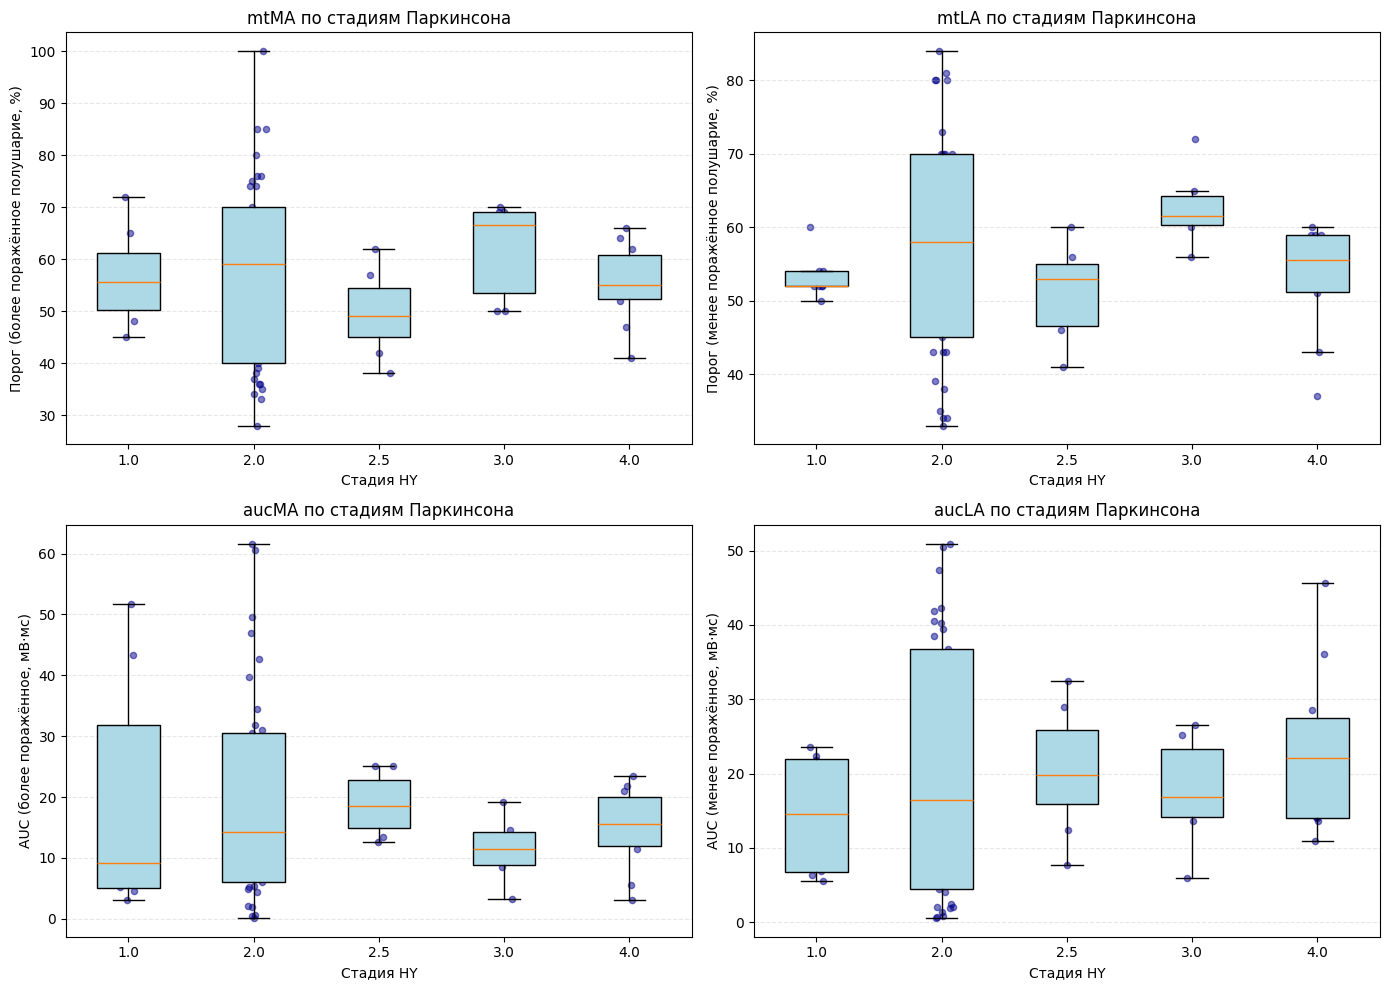

/var/folders/vb/ln0by8yd5g188n3xwgtwx5dr0000gn/T/ipykernel_6778/1814566540.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tms, x='Sex', y='mtMA', ax=axes[0], palette='Set2')
/var/folders/vb/ln0by8yd5g188n3xwgtwx5dr0000gn/T/ipykernel_6778/1814566540.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tms, x='Sex', y='aucMA', ax=axes[1], palette='Set2')


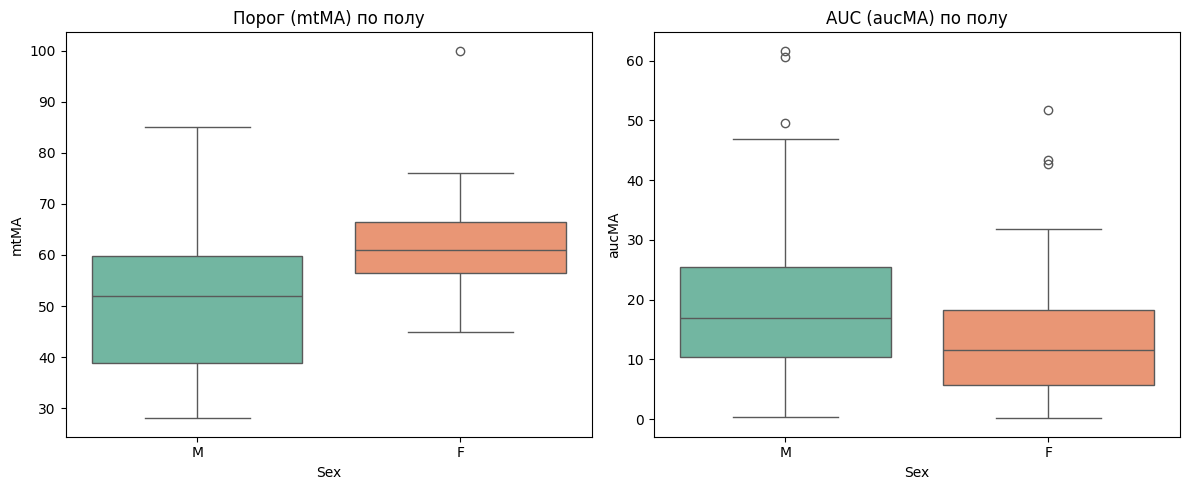

In [4]:
# Приводим HY к категории для удобства (есть полуцелые значения)
df_tms['HY_cat'] = df_tms['HY'].astype(str)

# Список для графиков: два основных параметра - порог и AUC (сильная реакция)
params_to_plot = [
    ('mtMA', 'Порог (более поражённое полушарие, %)', 'mtMA_plot'),
    ('mtLA', 'Порог (менее поражённое полушарие, %)', 'mtLA_plot'),
    ('aucMA', 'AUC (более поражённое, мВ·мс)', 'aucMA_plot'),
    ('aucLA', 'AUC (менее поражённое, мВ·мс)', 'aucLA_plot')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (col, ylabel, _) in enumerate(params_to_plot):
    ax = axes[idx]
    # Убираем выбросы для наглядности (можно оставить)
    data_to_plot = [df_tms[df_tms['HY'] == hy][col].dropna() for hy in sorted(df_tms['HY'].unique())]
    bp = ax.boxplot(data_to_plot, labels=sorted(df_tms['HY'].unique()), 
                    patch_artist=True, showfliers=False)
    # Заливка цветом
    for box in bp['boxes']:
        box.set_facecolor('lightblue')
    # Добавляем точки
    for i, hy in enumerate(sorted(df_tms['HY'].unique())):
        y = df_tms[df_tms['HY'] == hy][col].dropna()
        x = np.random.normal(i+1, 0.04, size=len(y))
        ax.scatter(x, y, alpha=0.5, s=20, color='darkblue')
    ax.set_xlabel('Стадия HY')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{col} по стадиям Паркинсона')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Дополнительно: распределение порога и AUC по полу (если нужно)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_tms, x='Sex', y='mtMA', ax=axes[0], palette='Set2')
axes[0].set_title('Порог (mtMA) по полу')
sns.boxplot(data=df_tms, x='Sex', y='aucMA', ax=axes[1], palette='Set2')
axes[1].set_title('AUC (aucMA) по полу')
plt.tight_layout()
plt.show()

# 4. Сравнение порогов patient_12 с выборкой ПД из TMS.csv

У нас есть:

patient_12 из первого датасета: threshold_left = 55, threshold_right = 50.0 (после конвертации) – из вашего CSV-файла кандидатов.

Во втором датасете пороги: mtMA (более поражённое) и mtLA (менее поражённое). Поскольку у пациента с хронической болью нет асимметрии, будем сравнивать threshold_left с mtLA (предполагая, что левое полушарие соответствует менее поражённому у правшей – это допущение). Либо сравнить среднее (threshold_left+threshold_right)/2 со средним (mtMA+mtLA)/2 у ПД.

In [5]:
# Значения порогов пациента
patient_threshold_left = 55.0
patient_threshold_right = 50.0
patient_mean_threshold = (patient_threshold_left + patient_threshold_right) / 2

# Берём только первый визит (T1) для независимости наблюдений
df_t1 = df_tms[df_tms['Period'] == 'T1'].copy()
# Удаляем строки, где нет порогов
df_t1 = df_t1.dropna(subset=['mtMA', 'mtLA'])

# Средние пороги в группе ПД
mean_mtMA = df_t1['mtMA'].mean()
std_mtMA = df_t1['mtMA'].std()
mean_mtLA = df_t1['mtLA'].mean()
std_mtLA = df_t1['mtLA'].std()
mean_mt_both = (df_t1['mtMA'] + df_t1['mtLA']).mean()
std_mt_both = (df_t1['mtMA'] + df_t1['mtLA']).std()

print("=== СРАВНЕНИЕ ПОРОГОВ PATIENT_12 С ГРУППОЙ ПД (T1) ===\n")
print(f"Пациент (хроническая боль): left={patient_threshold_left}, right={patient_threshold_right}, среднее={patient_mean_threshold:.1f}")
print(f"\nГруппа ПД (n={len(df_t1)}):")
print(f"  mtMA (более поражённое): {mean_mtMA:.1f} ± {std_mtMA:.1f}")
print(f"  mtLA (менее поражённое): {mean_mtLA:.1f} ± {std_mtLA:.1f}")
print(f"  Среднее из двух полушарий: {mean_mt_both:.1f} ± {std_mt_both:.1f}")

# Z-score для правого порога (50) относительно mtMA (более поражённое)
z_right_vs_MA = (patient_threshold_right - mean_mtMA) / std_mtMA
z_left_vs_LA = (patient_threshold_left - mean_mtLA) / std_mtLA
z_mean_vs_mean = (patient_mean_threshold - mean_mt_both) / std_mt_both

print(f"\nСравнение (Z-score):")
print(f"  threshold_right vs mtMA: Z = {z_right_vs_MA:.2f}")
print(f"  threshold_left vs mtLA: Z = {z_left_vs_LA:.2f}")
print(f"  среднее порогов vs среднее mtMA+mtLA: Z = {z_mean_vs_mean:.2f}")

# Процентили
percentile_right = stats.percentileofscore(df_t1['mtMA'], patient_threshold_right)
percentile_left = stats.percentileofscore(df_t1['mtLA'], patient_threshold_left)
percentile_mean = stats.percentileofscore((df_t1['mtMA']+df_t1['mtLA'])/2, patient_mean_threshold)

print(f"\nПроцентили в группе ПД:")
print(f"  threshold_right ниже, чем {percentile_right:.1f}% пациентов с ПД")
print(f"  threshold_left ниже, чем {percentile_left:.1f}% пациентов с ПД")
print(f"  среднее ниже, чем {percentile_mean:.1f}% пациентов с ПД")

=== СРАВНЕНИЕ ПОРОГОВ PATIENT_12 С ГРУППОЙ ПД (T1) ===

Пациент (хроническая боль): left=55.0, right=50.0, среднее=52.5

Группа ПД (n=11):
  mtMA (более поражённое): 61.2 ± 16.1
  mtLA (менее поражённое): 60.1 ± 11.2
  Среднее из двух полушарий: 121.3 ± 24.5

Сравнение (Z-score):
  threshold_right vs mtMA: Z = -0.69
  threshold_left vs mtLA: Z = -0.45
  среднее порогов vs среднее mtMA+mtLA: Z = -2.81

Процентили в группе ПД:
  threshold_right ниже, чем 18.2% пациентов с ПД
  threshold_left ниже, чем 27.3% пациентов с ПД
  среднее ниже, чем 18.2% пациентов с ПД


# 5. Визуализация сравнения

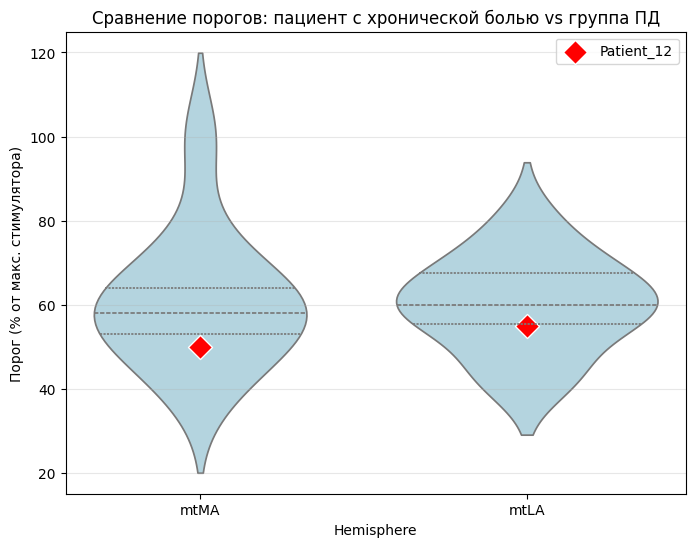

In [6]:
# Подготовим данные для графика: значения порогов пациентов ПД и patient_12
pd_thresholds = df_t1[['mtMA', 'mtLA']].melt(var_name='Hemisphere', value_name='Threshold')
pd_thresholds['Group'] = 'Паркинсон'

# Добавим данные пациента
patient_data = pd.DataFrame({
    'Hemisphere': ['mtMA', 'mtLA'],
    'Threshold': [patient_threshold_right, patient_threshold_left],
    'Group': ['Наш пациент (боль)'] * 2
})

combined = pd.concat([pd_thresholds, patient_data], ignore_index=True)

plt.figure(figsize=(8, 6))
sns.violinplot(data=pd_thresholds, x='Hemisphere', y='Threshold', inner='quartile', color='lightblue')
sns.scatterplot(data=patient_data, x='Hemisphere', y='Threshold', s=150, color='red', marker='D', label='Patient_12')
plt.ylabel('Порог (% от макс. стимулятора)')
plt.title('Сравнение порогов: пациент с хронической болью vs группа ПД')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# 6. Вывод и интерпретация

In [7]:
print("\n=== ИНТЕРПРЕТАЦИЯ ===\n")
if abs(z_mean_vs_mean) > 2:
    print(f"✅ Пороги пациента значительно отличаются от типичных порогов при ПД (|Z| = {abs(z_mean_vs_mean):.2f} > 2).")
    print("   Это указывает на атипичный ТМС-ответ, который может быть биомаркером.")
elif abs(z_mean_vs_mean) > 1:
    print(f"⚠️ Пороги пациента умеренно отличаются от группы ПД (Z = {z_mean_vs_mean:.2f}).")
    print("   Требуется осторожная интерпретация.")
else:
    print(f"❌ Пороги пациента лежат в пределах нормы для ПД (Z = {z_mean_vs_mean:.2f}).")
    print("   ТМС-ответ не является выдающимся на фоне других пациентов с ПД.")


=== ИНТЕРПРЕТАЦИЯ ===

✅ Пороги пациента значительно отличаются от типичных порогов при ПД (|Z| = 2.81 > 2).
   Это указывает на атипичный ТМС-ответ, который может быть биомаркером.
